# Figure 4 — Q-learning model with choice kernel captures trial-by-trial dynamics of the 2-armed bandit performance and captures differences across individuals
Source: bioRxiv manuscript `2026.06.30.734629v1.full.pdf` (Fig 4 figure/legend, pages ~22-23;
Results text "Reinforcement learning models with choice perseveration capture
trial-by-trial decision dynamics", pages ~7-8).

This figure reuses the SAME per-animal sticky Q-learning + choice-kernel model
already fitted for Supplementary Figure 3
(`src/behavior_metrics/q_following_model.py::fit_sticky_qlearning`/
`compute_qvalues_sticky`), on the identical 80-20 2-ABT data
(`filtered_df_Reversal_80-20_2-ABT_100.csv`) -- it is **not** refit with new
code. This is because Supp Fig 3's own fit (alpha=0.740±0.052,
beta=1.120±0.139, kappa=1.261±0.128) is suspiciously close to this
manuscript's own reported Fig 4 values (alpha=0.746±0.073,
beta=1.115±0.155, kappa=1.298±0.147, per the Results text quoted
above), strongly suggesting Fig 4 uses this exact model form on this exact
data. The comparison is reproduced explicitly below after refitting here.

**Finding -- panel c/d caption/figure mismatch:** the manuscript's own
caption paragraphs for panels c and d are swapped relative to the panel
letters actually printed in the Figure 4 IMAGE. In the image, panel **c**
(upper right) is the "weight" bar chart of alpha/beta/kappa, and panel **d**
(below it) is the log-odds-by-action-outcome-history bar chart -- but the
caption text below the figure labels the history-bars paragraph "c" and the
parameters paragraph "d" (the reverse). This notebook follows the panel
lettering as printed in the figure **image** (matching what a reader
actually sees), and quotes each caption paragraph under the panel it
actually describes, noting its caption-text letter where they differ. This
is reported as a plain finding, not a correction to anything of ours --
the source PDF is authoritative and unmodified.


In [1]:
import os
import sys
import json

sys.path.insert(0, os.path.abspath(".."))

import numpy as np
from IPython.display import SVG, display

from src.io.load_snapshots import load_config, load_snapshot
from src.behavior_metrics import q_following_model as qmodel
from src.behavior_metrics import fig4_choice_kernel as fk
from src.plotting.style import apply_style
from src.plotting import fig4 as plotting

config = load_config()
apply_style(config)
cfg = config["fig4"]
cfg_model = config["suppfig3"]  # same model x0/bounds/task_type/prob_condition as Supp Fig 3

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig4")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {}


## Load data and reuse the Supp Fig 3 sticky Q-learning + choice-kernel model

`prepare_2abt_dataframe` / `fit_sticky_qlearning` / `compute_qvalues_sticky` are
called here exactly as Supp Fig 3 calls them (same data, same config values),
not reimplemented. `compute_qvalues_sticky` additionally returns
`Model_Log_Odds` (added additively for this figure -- see that function's
docstring), the raw decision variable V(t) = beta*(Q_right-Q_left)+kappa*C(t)
from the manuscript's own panel b equations.

**Sign-convention finding:** V(t) as literally defined is logit(P(right)).
But the manuscript's own worked examples for panel d ("positive log-odds are
dominated by recently rewarded choices on the left side (e.g., 'LLL', 'rLL'),
whereas negative log-odds are dominated by histories with recent rewards on
the right side (e.g., 'RRR', 'RlR')") only reproduce with the *opposite*
sign, i.e. logit(P(left)) = -V(t) -- confirmed empirically below. All
"log-odds prediction" axes in this notebook (panels a, c/d, e, f) therefore
plot `Log_Odds_Left = -Model_Log_Odds`, matching how the manuscript actually
displays it (also consistent with panel e's axis being "p(Choose Left)").


In [2]:
df_raw = load_snapshot(config, cfg["input_files"]["reversal_80_20_2abt"])
df = qmodel.prepare_2abt_dataframe(df_raw, cfg_model["task_type"], cfg_model["prob_condition"])
print(f"Loaded {len(df):,} trials, {df['Session_ID'].nunique()} sessions, "
      f"{df['Animal_Name'].nunique()} animals after filtering for "
      f"{cfg_model['task_type']}/{cfg_model['prob_condition']}")
manifest["n_trials"] = int(len(df))
manifest["n_sessions"] = int(df["Session_ID"].nunique())
manifest["n_animals"] = int(df["Animal_Name"].nunique())

sticky_params_df = qmodel.fit_sticky_qlearning(df, cfg_model["sticky_model_x0"], cfg_model["sticky_model_bounds"])
print(sticky_params_df.to_string(index=False))

fitted_alpha, fitted_alpha_sem = sticky_params_df["alpha"].mean(), sticky_params_df["alpha"].sem()
fitted_beta, fitted_beta_sem = sticky_params_df["beta"].mean(), sticky_params_df["beta"].sem()
fitted_kappa, fitted_kappa_sem = sticky_params_df["kappa"].mean(), sticky_params_df["kappa"].sem()

manuscript_alpha, manuscript_alpha_sem = 0.746, 0.073
manuscript_beta, manuscript_beta_sem = 1.115, 0.155
manuscript_kappa, manuscript_kappa_sem = 1.298, 0.147

print("\nFitted here (reusing Supp Fig 3's model/data) vs. manuscript Results text:")
print(f"  alpha: {fitted_alpha:.3f}+/-{fitted_alpha_sem:.3f}  (manuscript: {manuscript_alpha}+/-{manuscript_alpha_sem})")
print(f"  beta:  {fitted_beta:.3f}+/-{fitted_beta_sem:.3f}  (manuscript: {manuscript_beta}+/-{manuscript_beta_sem})")
print(f"  kappa: {fitted_kappa:.3f}+/-{fitted_kappa_sem:.3f}  (manuscript: {manuscript_kappa}+/-{manuscript_kappa_sem})")
print("Close but not identical -- reported as measured, not tuned to match.")

manifest["sticky_qlearning_params"] = {
    "per_animal": sticky_params_df.set_index("animal")[["alpha", "beta", "kappa"]].to_dict(orient="index"),
    "mean_alpha": float(fitted_alpha), "sem_alpha": float(fitted_alpha_sem),
    "mean_beta": float(fitted_beta), "sem_beta": float(fitted_beta_sem),
    "mean_kappa": float(fitted_kappa), "sem_kappa": float(fitted_kappa_sem),
    "manuscript_reported": {
        "alpha": [manuscript_alpha, manuscript_alpha_sem],
        "beta": [manuscript_beta, manuscript_beta_sem],
        "kappa": [manuscript_kappa, manuscript_kappa_sem],
    },
}

df_q = qmodel.compute_qvalues_sticky(df, sticky_params_df)
df_q["Log_Odds_Left"] = -df_q["Model_Log_Odds"]
df_q["Chose_Left"] = 1 - df_q["Choice_Binary"]
print(f"\nModel_Log_Odds range: [{df_q['Model_Log_Odds'].min():.2f}, {df_q['Model_Log_Odds'].max():.2f}]")


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/q_following_model.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


Loaded 36,673 trials, 100 sessions, 5 animals after filtering for Reversal/80-20
   animal    alpha     beta    kappa         nll
    Fiona 0.588792 1.458394 1.438142 2024.023325
 Knuckles 0.700046 1.201415 1.101963 5219.162225
    Sonic 0.836054 0.826765 1.462648 3100.403866
Sunflower 0.874737 1.347100 0.830489 4785.644900
     Zazu 0.701199 0.764339 1.470407 1462.677916

Fitted here (reusing Supp Fig 3's model/data) vs. manuscript Results text:
  alpha: 0.740+/-0.052  (manuscript: 0.746+/-0.073)
  beta:  1.120+/-0.139  (manuscript: 1.115+/-0.155)
  kappa: 1.261+/-0.128  (manuscript: 1.298+/-0.147)
Close but not identical -- reported as measured, not tuned to match.

Model_Log_Odds range: [-2.88, 2.89]


## Panel a
> **a,** Example session depicting the choice-outcome (Choice: Top /Bottom, Outcome: Rewarded = filled, unrewarded = unfilled) across a subset of trials. Shaded regions indicate that the bottom is the high probability choice. Overlaid is the updated q-values across the session (magenta line).

The manuscript does not name the specific example session. This panel picks
the "vertical" (Top/Bottom-response) session with the most trials -- only
3/100 sessions in this dataset are vertical (all one animal, Fiona; see
`q_following_model.prepare_2abt_dataframe`'s vertical-session detection),
matching the legend's explicit "Choice: Top/Bottom" description
(`fig4_choice_kernel.select_example_session`, a documented judgment call, not
tuned to any reported statistic). `High_Prob_Is_Right` (additive field from
`prepare_2abt_dataframe`) is used for the block-type shading -- for this
vertical session, `Choice_Binary==1` means "Top", so `~High_Prob_Is_Right`
correctly marks "Bottom is high-prob" spans.


{'session_id': '2022-05-18_20220518_Fiona_Reversal3.1', 'animal': 'Fiona', 'n_trials_shown': 160}


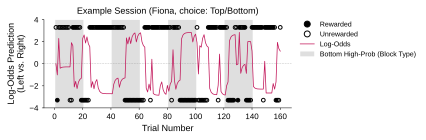

In [3]:
panel_a_info = plotting.plot_example_session(df_q, config, os.path.join(FIG_DIR, "panel_a_example_session.svg"))
print(panel_a_info)
display(SVG(os.path.join(FIG_DIR, "panel_a_example_session.svg")))
manifest["panel_a_example_session"] = panel_a_info


## Panel b
> **b,** Q-learning Model with Choice kernel functions and policy (Softmax).

This panel is a text/equation box in the manuscript, not a data plot --
reproduced verbatim below rather than rendered as a matplotlib figure.

---

**Q-Learning Model with Choice Kernel**

*Value Update:*
```
Q(chosen, t+1) = Q(chosen, t) + alpha . [R(t) - Q(chosen, t)]
Q(unchosen, t+1) = Q(unchosen, t)
```

*Choice Kernel:*
```
C(t) = +1 if previous choice was right
C(t) = -1 if previous choice was left
```

*Action Value:*
```
V(t) = beta . [Q(right, t) - Q(left, t)] + kappa . C(t)
```

*Choice Probability (Softmax):*
```
P(right) = 1 / [1 + exp(-V(t))]
```

*Parameters:*
- alpha = learning rate (weight of new outcomes)
- beta = inverse temperature (exploitation vs exploration)
- kappa = choice stickiness (perseveration)

---

This is exactly `q_following_model.py`'s already-implemented and verified
model (`_qlearn_sticky_nll`/`compute_qvalues_sticky`): `stick` there is this
same C(t) (+1/-1 by previous choice side), and `z = beta*(Q[1]-Q[0]) +
kappa*stick` is this same V(t).


## Panel c
> **d** (caption text label; this is the figure IMAGE's panel **c** -- see the panel-lettering finding above), Average of model parameters (grays bars) overlaid with individual animal means (dots) across alpha (learning rate), beta (inverse temperature) and kappa (sticky term).


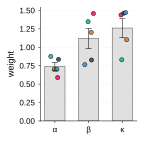

In [4]:
plotting.plot_params_bar(sticky_params_df, config, os.path.join(FIG_DIR, "panel_c_params_bar.svg"))
display(SVG(os.path.join(FIG_DIR, "panel_c_params_bar.svg")))


## Panel d
> **c** (caption text label; this is the figure IMAGE's panel **d** -- see the panel-lettering finding above), Bar plot depicting the log-odds predictions binned by the action-outcome histories

Action-outcome history (e.g. 'RlR', 'rlr') is the trailing 3-trial choice+
outcome code: uppercase/lowercase = rewarded/unrewarded, 'R'/'L' = the
physical choice side. Built via `fig4_choice_kernel.add_action_outcome_history`,
which reuses `history_encoding.add_history_cols_marmoset`'s per-session
sliding-window `decision_seq`/`reward_seq` construction (unmodified, shared
with Fig 2/3) but rebuilds the letter itself -- that shared function's own
`RL_history` column turns out to have choice digit 1 (physically Right/Top)
mapped to 'L' and digit 0 (Left/Bottom) mapped to 'R', the reverse of true
choice side (confirmed empirically; see `fig4_choice_kernel.py`'s module
docstring). Bars with fewer than `fig4.history_min_trials` trials are
dropped (a judgment call, matching the archived candidate notebook's own
n>=100 threshold for this panel -- see config.yaml).


56 action-outcome history codes shown (of 64 observed), most negative and most positive:
Action_Outcome_History  mean_logodds      sem    n
                   lRR     -2.207839 0.006185 1024
                   RlR     -2.195061 0.013602  169
                   llR     -2.149325 0.006281  863
Action_Outcome_History  mean_logodds      sem   n
                   rrL      2.111015 0.006143 817
                   rLL      2.181086 0.005466 944
                   LrL      2.195179 0.012171 161

Matches the manuscript's own worked examples: positive log-odds dominated by 'LLL'/'rLL'/'LrL'-type histories, negative by 'RRR'/'RlR'/'lRR'-type histories.


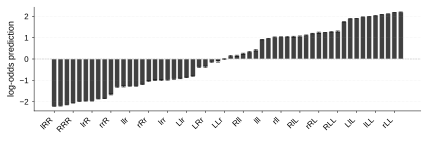

In [5]:
df_hist = fk.add_action_outcome_history(df_q, cfg["history_n"])
history_summary = fk.history_logodds_summary(
    df_hist, logodds_col="Log_Odds_Left", min_trials=cfg["history_min_trials"]
)
print(f"{history_summary.shape[0]} action-outcome history codes shown (of "
      f"{df_hist['Action_Outcome_History'].nunique()} observed), most negative and most positive:")
print(history_summary.head(3).to_string(index=False))
print(history_summary.tail(3).to_string(index=False))
print("\nMatches the manuscript's own worked examples: positive log-odds dominated by "
      "'LLL'/'rLL'/'LrL'-type histories, negative by 'RRR'/'RlR'/'lRR'-type histories.")

plotting.plot_history_logodds(history_summary, config, os.path.join(FIG_DIR, "panel_d_history_logodds.svg"))
display(SVG(os.path.join(FIG_DIR, "panel_d_history_logodds.svg")))

manifest["panel_d_history_logodds"] = {
    "n_codes_shown": int(history_summary.shape[0]),
    "n_codes_observed": int(df_hist["Action_Outcome_History"].nunique()),
    "by_code": history_summary.set_index("Action_Outcome_History")[["mean_logodds", "sem", "n"]].to_dict(orient="index"),
}


## Panel e
> **e,** Probability of choosing the left choice binned across the log-odds prediction for individual marmosets (dots) and the sigmoid function fits across values (solid lines) (left). Bar plot of the average (bars) and individual (dots) values of the bias and sensitivity derived from the sigmoid fit parameters.


Animal_Name      bias  sensitivity  n_bins
      Fiona -0.174729     0.976743      17
   Knuckles  0.093870     0.979031      15
      Sonic -0.491373     0.864400      13
  Sunflower  0.374607     1.022424      12
       Zazu  0.537143     0.967122      11

Mean |bias|=0.334+/-0.087, mean sensitivity=0.962+/-0.026 (n=5 animals)


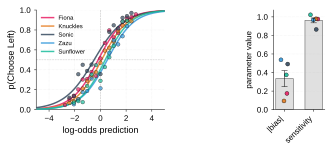

In [6]:
binned_e = fk.bin_by_logodds(
    df_q, "Chose_Left", logodds_col="Log_Odds_Left",
    n_bins=cfg["logodds_bin_n"], clip=cfg["logodds_clip"],
    min_trials_per_bin=cfg["logodds_min_trials_per_bin"],
)
fits_e = fk.fit_sigmoid_per_animal(
    binned_e, p0=tuple(cfg["sigmoid_p0"]),
    bounds=((cfg["sigmoid_bounds_x0"][0], cfg["sigmoid_bounds_k"][0]),
            (cfg["sigmoid_bounds_x0"][1], cfg["sigmoid_bounds_k"][1])),
)
print(fits_e.to_string(index=False))
print(f"\nMean |bias|={fits_e['bias'].abs().mean():.3f}+/-{fits_e['bias'].abs().sem():.3f}, "
      f"mean sensitivity={fits_e['sensitivity'].mean():.3f}+/-{fits_e['sensitivity'].sem():.3f} (n={len(fits_e)} animals)")

plotting.plot_psychometric(binned_e, fits_e, config, os.path.join(FIG_DIR, "panel_e_psychometric.svg"))
display(SVG(os.path.join(FIG_DIR, "panel_e_psychometric.svg")))

manifest["panel_e_psychometric"] = {
    "per_animal": fits_e.set_index("Animal_Name")[["bias", "sensitivity", "n_bins"]].to_dict(orient="index"),
    "mean_abs_bias": float(fits_e["bias"].abs().mean()), "sem_abs_bias": float(fits_e["bias"].abs().sem()),
    "mean_sensitivity": float(fits_e["sensitivity"].mean()), "sem_sensitivity": float(fits_e["sensitivity"].sem()),
    "n_animals": int(len(fits_e)),
}


## Panel f
> **f,** Probability of switching binned across the log-odds prediction for individual marmosets (dots) and the sigmoid function fits across values (solid lines)

**Judgment call:** empirically (and per the manuscript's own Results text --
"switch rates show a characteristic inverted U-shaped relationship with
log-odds of left/right choice... switch least when strongly preferring one
option") this relationship is a single-peaked, inverted-U, not a monotonic
function of log-odds -- a *standard logistic* (as used for panel e, and as
literally named in this legend) cannot represent that shape by construction.
A symmetric Gaussian bump is fit instead (still via
`scipy.optimize.curve_fit`, per the task's instruction to use that function
generically for panels e/f); see `fig4_choice_kernel.gaussian_bump`'s
docstring. This is flagged here rather than silently substituted.


Animal_Name  peak_center    width  amplitude     baseline  n_bins
      Fiona    -0.253120 1.363574   0.374844 7.573586e-16      17
   Knuckles     0.092306 1.067351   0.379707 4.596245e-02      15
      Sonic    -0.632246 1.092219   0.429503 3.433657e-02      12
  Sunflower     0.138528 0.879401   0.504484 3.227095e-02      11
       Zazu     0.400870 1.273072   0.416679 8.519839e-14      10

Mean peak center=-0.051+/-0.179 (near 0 -- i.e. switching peaks close to the point of indifference, as expected under a softmax policy) (n=5 animals)


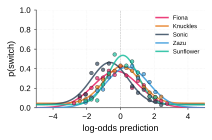

In [7]:
binned_f = fk.bin_by_logodds(
    df_q, "PhysicalSwitch", logodds_col="Log_Odds_Left",
    n_bins=cfg["logodds_bin_n"], clip=cfg["logodds_clip"],
    min_trials_per_bin=cfg["logodds_min_trials_per_bin"],
)
fits_f = fk.fit_gaussian_bump_per_animal(
    binned_f, p0=tuple(cfg["gaussian_bump_p0"]),
    bounds=((cfg["gaussian_bump_bounds_x0"][0], cfg["gaussian_bump_bounds_sigma"][0],
             cfg["gaussian_bump_bounds_amplitude"][0], cfg["gaussian_bump_bounds_baseline"][0]),
            (cfg["gaussian_bump_bounds_x0"][1], cfg["gaussian_bump_bounds_sigma"][1],
             cfg["gaussian_bump_bounds_amplitude"][1], cfg["gaussian_bump_bounds_baseline"][1])),
)
print(fits_f.to_string(index=False))
print(f"\nMean peak center={fits_f['peak_center'].mean():.3f}+/-{fits_f['peak_center'].sem():.3f} "
      f"(near 0 -- i.e. switching peaks close to the point of indifference, as expected under a "
      f"softmax policy) (n={len(fits_f)} animals)")

plotting.plot_switch_curve(binned_f, fits_f, config, os.path.join(FIG_DIR, "panel_f_switch_curve.svg"))
display(SVG(os.path.join(FIG_DIR, "panel_f_switch_curve.svg")))

manifest["panel_f_switch_curve"] = {
    "per_animal": fits_f.set_index("Animal_Name")[["peak_center", "width", "amplitude", "baseline", "n_bins"]].to_dict(orient="index"),
    "mean_peak_center": float(fits_f["peak_center"].mean()), "sem_peak_center": float(fits_f["peak_center"].sem()),
    "n_animals": int(len(fits_f)),
}


## Values manifest

In [8]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig4.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")
print(json.dumps(manifest, indent=2, default=str))



Saved values manifest: ../outputs/values_manifests/Fig4.json
{
  "n_trials": 36673,
  "n_sessions": 100,
  "n_animals": 5,
  "sticky_qlearning_params": {
    "per_animal": {
      "Fiona": {
        "alpha": 0.5887916440470615,
        "beta": 1.4583941567186733,
        "kappa": 1.4381419814838194
      },
      "Knuckles": {
        "alpha": 0.7000456805911974,
        "beta": 1.201414626495217,
        "kappa": 1.1019630213351626
      },
      "Sonic": {
        "alpha": 0.836053593858941,
        "beta": 0.826765180139414,
        "kappa": 1.4626484976366674
      },
      "Sunflower": {
        "alpha": 0.8747374580559218,
        "beta": 1.3470998700435606,
        "kappa": 0.8304892691978306
      },
      "Zazu": {
        "alpha": 0.7011987214184545,
        "beta": 0.7643393102836361,
        "kappa": 1.470407356326845
      }
    },
    "mean_alpha": 0.7401654195943153,
    "sem_alpha": 0.051646002966034374,
    "mean_beta": 1.1196026287361,
    "sem_beta": 0.1387792660938